In [27]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

from mis_dro.plot import *
from mis_dro.experiments import ExperimentName

# from matplotlib import rc
# rc('font', **{'family': 'serif', 'serif': ['Computer Modern'], "size":12})
# rc('text', usetex=True)

In [28]:
experiment_name = ExperimentName.kl_newsvendor_1d
# experiment_dir = Path(f"/Users/patrick/experiments/misdro/{experiment_name.value}")
experiment_dir = Path(f"/dcs/large/u1508153/misdro/dro_bas/{experiment_name.value}")
assert experiment_dir.exists()
all_results_df = pd.read_csv(experiment_dir / "results.csv", index_col=["uuid", "replication"])

num_total_samples = []
for _, row in all_results_df.iterrows():
    if row["algorithm"] == "kl_bdro":
        num_total_samples.append(row["num_likelihood_samples"] ** 2)
    elif row["algorithm"] == "kl_dro_bas":
        num_total_samples.append(row["num_likelihood_samples"])
all_results_df["num_total_samples"] = num_total_samples
all_results_df

solution  dgp_time  \
uuid                                 replication                      
99054ac5-d1c6-4ff1-b027-bb65789b1256 0              [inf]  0.001798   
                                     1              [inf]  0.000215   
                                     2              [inf]  0.000164   
                                     3              [inf]  0.000174   
                                     4              [inf]  0.000156   
...                                                   ...       ...   
38a743b9-b3a0-4df5-9ed1-77907a29b085 495            [inf]  0.000155   
                                     496            [inf]  0.000152   
                                     497            [inf]  0.000146   
                                     498            [inf]  0.000146   
                                     499            [inf]  0.000146   

                                                  likelihood_time  \
uuid                                 replication                    
99054ac5-d1c6-4ff1-b027-bb65789b1256 0                   0.000014   
                                     1                   0.000011   
                                     2                   0.000010   
                                     3                   0.000012   
                                     4                   0.000011   
...                                                           ...   
38a743b9-b3a0-4df5-9ed1-77907a29b085 495                 0.000081   
                                     496                 0.000079   
                                     497                 0.000079   
                                     498                 0.000087   
                                     499                 0.000078   

                                                  posterior_time  solve_time  \
uuid                                 replication                               
99054ac5-d1c6-4ff1-b027-bb65789b1256 0                  0.001570    0.000012   
                                     1                  0.000050    0.000009   
                                     2                  0.000051    0.000009   
                                     3                  0.000048    0.000009   
                                     4                  0.000046    0.000009   
...                                                          ...         ...   
38a743b9-b3a0-4df5-9ed1-77907a29b085 495                0.000018    0.000009   
                                     496                0.000017    0.000008   
                                     497                0.000018    0.000008   
                                     498                0.000017    0.000009   
                                     499                0.000017    0.000008   

                                                  setup_time  \
uuid                                 replication               
99054ac5-d1c6-4ff1-b027-bb65789b1256 0                   0.0   
                                     1                   0.0   
                                     2                   0.0   
                                     3                   0.0   
                                     4                   0.0   
...                                                      ...   
38a743b9-b3a0-4df5-9ed1-77907a29b085 495                 0.0   
                                     496                 0.0   
                                     497                 0.0   
                                     498                 0.0   
                                     499                 0.0   

                                                  log_partition_constant  \
uuid                                 replication                           
99054ac5-d1c6-4ff1-b027-bb65789b1256 0                          0.046881   
                                     1                          0.046881   
                                     2           

In [29]:
# NOTE filter by DGP
filter_dgp = "normal"
results_df = all_results_df.loc[all_results_df["dgp"] == filter_dgp]

# NOTE filter out when log_partition_constant G is less than epsilon
results_df = results_df.loc[results_df["log_partition_constant"] < results_df["epsilon"]]

def convert_str_to_float_list(str_list: str, list_len: int) -> list[float]:
    if str_list == "[]":
        return [np.nan for _ in range(list_len)]
    else:
        return [float(x) for x in str_list.strip('[]').split(',')]

# NOTE we always want the same number of test observations
assert np.isclose(results_df["num_test_observations"].var(), 0)
num_test_observations = results_df["num_test_observations"].unique()[0]
results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: convert_str_to_float_list(x, num_test_observations))

# special case for 1 test observation
if num_test_observations == 1:
    results_df["out_of_sample_cost"] = results_df["out_of_sample_cost"].map(lambda x: x[0])
else:
    raise NotImplementedError("Not supported yet!")

results_df["out_of_sample_cost"]

uuid                                  replication
7f8d85c5-e0a7-4bea-9be4-35ffbf901efc  0              14.534610
                                      1               4.378978
                                      2               2.492376
                                      3              13.399196
                                      4              23.399485
                                                       ...    
698b92fc-b1af-476c-85ca-28281989c0ac  495            19.869647
                                      496             0.001783
                                      497            50.023000
                                      498            33.939118
                                      499            15.379518
Name: out_of_sample_cost, Length: 73500, dtype: float64

In [30]:
gb = results_df.groupby(["algorithm", "epsilon", "posterior", "num_total_samples"])

def get_agg_df(results_df: pd.DataFrame, gb_cols: list[str]):

    gb = results_df.groupby(by=gb_cols)
    agg_df = gb.agg(
        out_of_sample_mean = pd.NamedAgg(column="out_of_sample_cost", aggfunc=np.mean),
        out_of_sample_var = pd.NamedAgg(column="out_of_sample_cost", aggfunc=np.var),
        mean_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.mean),
        std_solve_time = pd.NamedAgg(column="solve_time", aggfunc=np.std),
    )
    return agg_df

agg_df = get_agg_df(results_df, ["algorithm", "dgp", "epsilon", "num_total_samples"])
agg_df

/tmp/dcs-tmp.u1508153/ipykernel_59237/4226869177.py:6: FutureWarning: The provided callable <function mean at 0x7f07fc5dda80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/tmp/dcs-tmp.u1508153/ipykernel_59237/4226869177.py:6: FutureWarning: The provided callable <function var at 0x7f07fc5ddd00> is currently using SeriesGroupBy.var. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "var" instead.
  agg_df = gb.agg(
/tmp/dcs-tmp.u1508153/ipykernel_59237/4226869177.py:6: FutureWarning: The provided callable <function mean at 0x7f07fc5dda80> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  agg_df = gb.agg(
/tmp/dcs-tmp.u1508153/ipykernel_59237/4226869177.py:

out_of_sample_mean  \
algorithm  dgp    epsilon num_total_samples                       
kl_bdro    normal 0.001   25                          21.095511   
                          100                         20.439885   
                          900                         20.368834   
                  0.002   25                          21.080142   
                          100                         20.460128   
...                                                         ...   
kl_dro_bas normal 2.500   100                         27.407459   
                          900                         30.971449   
                  3.000   25                          24.764110   
                          100                         27.496969   
                          900                         31.828575   

                                             out_of_sample_var  \
algorithm  dgp    epsilon num_total_samples                      
kl_bdro    normal 0.001   25                        199.317100   
                          100                       177.140437   
                          900                       181.279843   
                  0.002   25                        199.294527   
                          100                       177.051682   
...                                                        ...   
kl_dro_bas normal 2.500   100                       241.551269   
                          900                       246.215277   
                  3.000   25                        220.927487   
                          100                       243.452995   
                          900                       253.513844   

                                             mean_solve_time  std_solve_time  
algorithm  dgp    epsilon num_total_samples                                   
kl_bdro    normal 0.001   25                        0.066666        0.011224  
                          100                       0.145099        0.019546  
                          900                       0.716372        0.031475  
                  0.002   25                        0.069686        0.011103  
                          100                       0.145815        0.019341  
...                                                      ...             ...  
kl_dro_bas normal 2.500   100                       0.034138        0.003413  
                          900                       0.381492        0.012309  
                  3.000   25                        0.021907        0.005817  
                          100                       0.035024        0.003358  
                          900                       0.386872        0.011753  

[147 rows x 4 columns]

## Plot mean-variance trade-off

For each DGP, we plot the out-of-sample mean $\hat{\mu}_M(\epsilon)$ and variance $\hat{\sigma}_M(\epsilon)$ of Bayesian DRO with different posteriors.

/tmp/dcs-tmp.u1508153/ipykernel_59237/1672573927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


/tmp/dcs-tmp.u1508153/ipykernel_59237/1672573927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
/tmp/dcs-tmp.u1508153/ipykernel_59237/1672573927.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)


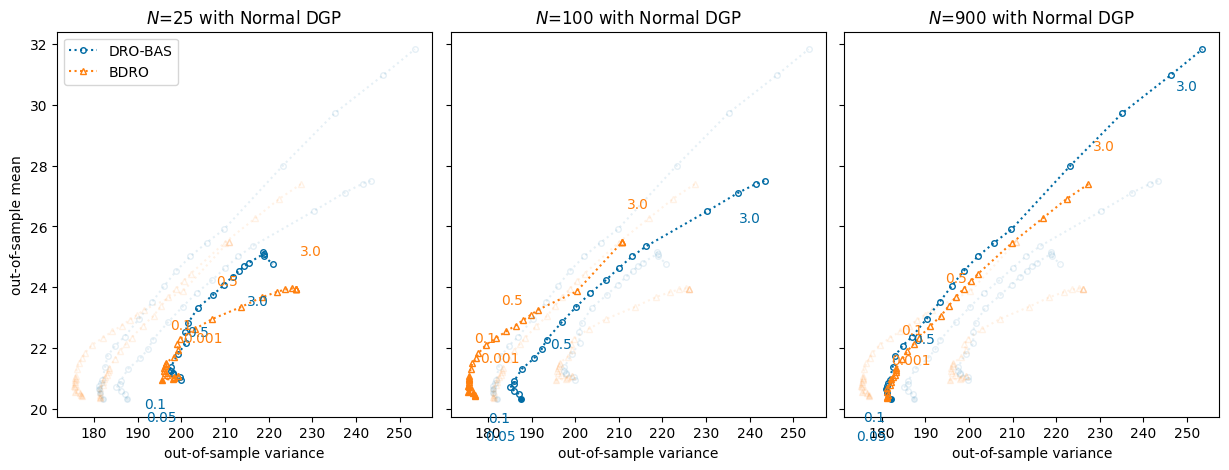

In [31]:
total_samples_sr = agg_df.index.get_level_values("num_total_samples")
TOTAL_SAMPLES = [25, 100, 900]

nrows = len(agg_df.index.get_level_values("dgp").unique())
ncols = len(TOTAL_SAMPLES)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, sharey=True, figsize=(5*ncols, nrows*5))
fig.subplots_adjust(wspace=0.05)
# fig.suptitle(NiceNameDGP[filter_dgp], fontsize=12)

for j, total_samples in enumerate(TOTAL_SAMPLES):
    df = agg_df.loc[total_samples_sr == total_samples]
    df.loc[:, "is_minimise_pareto_front"] = is_minimise_pareto_front(df["out_of_sample_var"].values, df["out_of_sample_mean"].values)
    gb = df.groupby("dgp")

    for k in range(len(TOTAL_SAMPLES)):
        if j == k:
            alpha = 1.0
            is_labelled = True
            axes[k].set_title("$N$" + f"={total_samples} with {NiceNameDGP[filter_dgp]}")
        else:
            alpha = 0.1
            is_labelled = False
        for i, (group, group_df) in enumerate(gb):
            index_set = set(
                zip(
                    group_df.index.get_level_values("algorithm"),
                    group_df.index.get_level_values("dgp"),
                )
            )
            if k == 0:
                axes[k].set_ylabel("out-of-sample mean")
                axes[k].legend()
            axes[k].set_xlabel("out-of-sample variance")
            
            # add a new plot on the same axis for each parameter setting
            for algorithm, dgp in index_set:
                style = algorithm_style(algorithm)
                line_label = ""
                if k == 0 and j == k:
                    line_label = style.pop("label")
                else:
                    style.pop("label")
                mean_variance_plot(axes[k], group_df.loc[algorithm, dgp, :], **style, alpha=alpha, is_labelled=is_labelled, label=line_label)
# fig.savefig(f"/Users/patrick/downloads/{experiment_name}_{filter_dgp}.pdf", bbox_inches="tight")
fig.show()

## Solve time

In [32]:
results_df["is_warm_start"] = results_df.index.get_level_values("replication") == 0

# solve_time_df = results_df.groupby(["algorithm", "dgp", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="dgp").unstack(level="algorithm")
solve_time_df = results_df.groupby(["algorithm", "num_total_samples", "is_warm_start"]).agg({"solve_time": ["mean", "std"]}).unstack(level="algorithm").swaplevel(1,2, axis="columns")

solve_time_df


solve_time                                
algorithm                          kl_bdro kl_dro_bas   kl_bdro kl_dro_bas
                                      mean       mean       std        std
num_total_samples is_warm_start                                           
25                False           0.065361   0.023573  0.011351   0.003514
                  True            0.081381   0.142115  0.002247   0.013915
100               False           0.143011   0.034289  0.019878   0.003536
                  True            0.155749   0.048935  0.004676   0.001853
900               False           0.687242   0.398921  0.033796   0.019826
                  True            0.717001   0.426133  0.015785   0.023199

In [33]:
print(solve_time_df.to_latex())

\begin{tabular}{llrrrr}
\toprule
 &  & \multicolumn{4}{r}{solve_time} \\
 & algorithm & kl_bdro & kl_dro_bas & kl_bdro & kl_dro_bas \\
 &  & mean & mean & std & std \\
num_total_samples & is_warm_start &  &  &  &  \\
\midrule
\multirow[t]{2}{*}{25} & False & 0.065361 & 0.023573 & 0.011351 & 0.003514 \\
 & True & 0.081381 & 0.142115 & 0.002247 & 0.013915 \\
\cline{1-6}
\multirow[t]{2}{*}{100} & False & 0.143011 & 0.034289 & 0.019878 & 0.003536 \\
 & True & 0.155749 & 0.048935 & 0.004676 & 0.001853 \\
\cline{1-6}
\multirow[t]{2}{*}{900} & False & 0.687242 & 0.398921 & 0.033796 & 0.019826 \\
 & True & 0.717001 & 0.426133 & 0.015785 & 0.023199 \\
\cline{1-6}
\bottomrule
\end{tabular}



# Constant $G(\tau_n)$ and expected KL

In [34]:

from bayesian_dro.Bayesian_DRO_continuous import DGP_STD_TRUNCATED_NORMAL
from mis_dro.constants import NUM_REPLICATIONS, NUM_OBSERVATIONS, NUM_TEST_OBSERVATIONS
from mis_dro.dataset import sample_dgp
from mis_dro.bayes_conjugates import default_prior_params, get_posterior_params, get_log_partition_constant, derive_analytical_posterior_params
from mis_dro.newsvendor import BACKORDER_COST, HOLDING_COST, newsvendor_cost_cvxpy

def normal_newsvendor_optimal_solution(dgp_mean, dgp_std):
    return sp.stats.norm.ppf(BACKORDER_COST / (BACKORDER_COST + HOLDING_COST), dgp_mean, dgp_std)


def expected_kl_normal_gamma(dgp_mean, dgp_std, theta_params):
    mu_posterior, _, alpha_posterior, beta_posterior = theta_params
    dgp_precision = 1 / (dgp_std ** 2)
    term1 = np.log(np.sqrt(dgp_precision * (beta_posterior / alpha_posterior)))
    term2 = (dgp_std ** 2 + (dgp_mean - mu_posterior)**2) / (2 * (beta_posterior / alpha_posterior))
    return term1 + term2 - 0.5 + get_log_partition_constant("normal_gamma", theta_posterior)

dgp = "multivariate_normal"
posterior = "normal_inverse_wishart"
num_observations = NUM_OBSERVATIONS
G_constant = []             # calculate the constant G
posterior_expected_kl = []  # assuming normal DGP, what is expectation under the posterior of the KL between the DGP and the likelihood?
prior_expected_kl = []      # assuming normal DGP, what is expectation under the prior of the KL between the DGP and the likelihood?
opt_sol = normal_newsvendor_optimal_solution(25, DGP_STD_TRUNCATED_NORMAL)  # optimal solution

opt_costs = np.zeros((NUM_REPLICATIONS, NUM_TEST_OBSERVATIONS))
for j in range(NUM_REPLICATIONS):
    generator = np.random.default_rng(seed=j)
    data = sample_dgp(
        dgp, num_observations, generator=generator
    )
    data_eval = sample_dgp(
        dgp, NUM_TEST_OBSERVATIONS, contamination=0.0, generator=generator
    )
    theta_prior = default_prior_params(posterior)
    theta_posterior = get_posterior_params(posterior, data, theta_prior)
    G_constant.append(get_log_partition_constant(posterior, theta_posterior))
    posterior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_posterior))
    prior_expected_kl.append(expected_kl_normal_gamma(25, DGP_STD_TRUNCATED_NORMAL, theta_prior))
    opt_costs[j] = newsvendor_cost_cvxpy(opt_sol, data_eval).value
np.max(G_constant), np.var(G_constant)

[[34.40648987]]


ValueError: Dimension mismatch: array 'cov' is of shape (1, 1), but 'mean' is a vector of length 5.

In [ ]:
np.mean(posterior_expected_kl), np.var(posterior_expected_kl)

(0.08892539135699731, 0.0022999465683889984)

In [ ]:
np.mean(prior_expected_kl), np.var(prior_expected_kl)

(359.7442957726813, 0.0)

# Mean squared error between our solution and the solution under the DGP


In [ ]:
mean_cost = np.mean(opt_costs, axis=1)
var_cost = np.var(opt_costs, axis=1)
mean_of_means = np.mean(mean_cost)
mean_of_variances = np.mean(var_cost)
var_of_means = np.var(mean_cost)
opt_sol, mean_of_variances, var_of_means

(31.045853465832373, 809.5869569415518, 16.31412063772674)

In [ ]:
def multivariate_digamma(a: float, p: int) -> float:
    """The multivariate digamma function of dimension p

    Notes:
        [1] https://search.r-project.org/CRAN/refmans/CholWishart/html/mvdigamma.html
        [2] https://en.wikipedia.org/wiki/Multivariate_gamma_function#Derivatives
    """
    return np.sum([sp.special.digamma(a + (1.0-i)/2.0) for i in range(p)])

def get_normal_inverse_wishart_G_constant(dim: int, kappa_post: float) -> float:
    """Returns the constant G(tau, nu) for the normal-inverse-Wishart"""
    term1 = -0.5 * dim * np.log(2)
    print(term1)
    term2 = - 0.5 * multivariate_digamma(0.5 * (kappa_post - dim - 2), dim)
    print(term2)
    term3 = dim / (2 * kappa_post)
    print(term3)
    term4 = dim * 0.5 * np.log(kappa_post - dim - 2)
    print(term4)
    # term5 = 0.5 * np.log(dim)
    # print(term5)
    return term1 + term2 + term3 + term4

In [ ]:
dim = 5
_, kappa_prior, _, _ = default_prior_params("normal_inverse_wishart", dim=dim)
kappa_post = kappa_prior +  20
kappa_prior, kappa_post

(13.0, 33.0)

In [ ]:
get_normal_inverse_wishart_G_constant(dim, kappa_post)

-1.7328679513998633
-6.208643562685282
0.07575757575757576
8.145241345053705


0.2794874067261359